In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Path to the dataset folder
DATA_ROOT = r"C:\Users\Asus\OneDrive\Desktop\MSc Cybersecurity -NTU\Major Project\Dataset\iot_23_datasets_small"

# --- Figure output: anchor to project root so saving works regardless of the
#     kernel's working directory ---
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)            # fixes "folder did not exist" bug
print("Figures will be saved to:", FIG_DIR)

def save_fig(name):
    """Save the current matplotlib figure into the figures folder."""
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches="tight")

# Find all labeled files
all_files = glob.glob(DATA_ROOT + "/**/*.labeled", recursive=True)
print(f"Found {len(all_files)} labeled files")

# --- EDA SAMPLING STRATEGY -------------------------------------------------
# Each IoT-23 capture is dominated by ONE behaviour: some files are benign,
# others are a specific attack. To ensure both classes and every
# attack type, a capped sample is taken from every file. This is an EDA sample to
# understand the data distribution - NOT the final training set (built in
# 02_preprocessing, where stratified sampling is applied).
ROWS_PER_FILE = 50000   # ~1.15M rows max across 23 files; comfortable in 40GB RAM
# ---------------------------------------------------------------------------

all_chunks = []
for filepath in all_files:
    filename = os.path.basename(filepath)

    # Read the column names from the Zeek "#fields" header line
    col_names = []
    with open(filepath) as f:
        for line in f:
            if line.startswith("#fields"):
                col_names = line.strip().split("\t")[1:]
                break

    rows_from_this_file = 0
    for chunk in pd.read_csv(filepath, sep="\t", comment="#",
                              header=None, low_memory=False,
                              chunksize=50000):

        chunk.columns = col_names

        # The last Zeek column merges 3 values: tunnel_parents, label, detailed_label
        last_col = chunk.columns[-1]
        split = chunk[last_col].str.strip().str.split(r"\s{2,}", expand=True, n=2, regex=True)

        if split.shape[1] == 3:
            split.columns = ["tunnel_parents", "label", "detailed_label"]
            chunk = chunk.drop(columns=[last_col])
            chunk = pd.concat([chunk, split], axis=1)

        # Standardise label casing so "Benign" and "benign" are treated the same
        chunk["label"] = chunk["label"].str.lower().str.strip()

        all_chunks.append(chunk)
        rows_from_this_file += len(chunk)

        # Cap rows PER FILE so every capture (benign and attack) is represented
        if rows_from_this_file >= ROWS_PER_FILE:
            break

# Combine everything into one dataframe
df = pd.concat(all_chunks, ignore_index=True)

print(f"\nTotal rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nLabel counts:\n{df['label'].value_counts()}")

Figures will be saved to: C:\Users\Asus\Desktop\Desktop\MSc Cybersecurity -NTU\Major Project\iot_anomaly_detection\outputs\figures
Found 23 labeled files

Total rows loaded: 746,662
Columns: ['ts', 'uid', 'id.orig_h', 'id.orig_p', 'id.resp_h', 'id.resp_p', 'proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'label', 'detailed_label']

Label counts:
label
malicious    637485
benign       109177
Name: count, dtype: int64


In [2]:
# Check the shape and first few rows
print("Shape:", df.shape)
print()

# Check what labels exist
print("Unique labels:")
print(df['label'].value_counts())
print()

# Check for missing values - Zeek logs use '-' for missing, not NaN
print("Sample of raw data:")
df.head(3)

Shape: (746662, 23)

Unique labels:
label
malicious    637485
benign       109177
Name: count, dtype: int64

Sample of raw data:


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed_label
0,1.540469e+09,CGm6jB4dXK71ZDWUDh,192.168.1.132,58687,216.239.35.4,123,udp,-,0.114184,48,...,-,0,Dd,1,76,1,76,-,benign,-
1,1.540469e+09,CnaDAG3n5r8eiG4su2,192.168.1.132,1900,239.255.255.250,1900,udp,-,160.367579,7536,...,-,0,D,24,8208,0,0,-,benign,-
2,1.540469e+09,CUrxU238nt0m6yTgKf,192.168.1.132,32893,216.239.35.8,123,udp,-,0.016986,48,...,-,0,Dd,1,76,1,76,-,benign,-


Benign: 109,177 (14.6%)
Malicious: 637,485 (85.4%)

NOTE: Class imbalance is significant - this matters for model evaluation.
Accuracy alone will be misleading. Will use AUPRC and F1 instead.


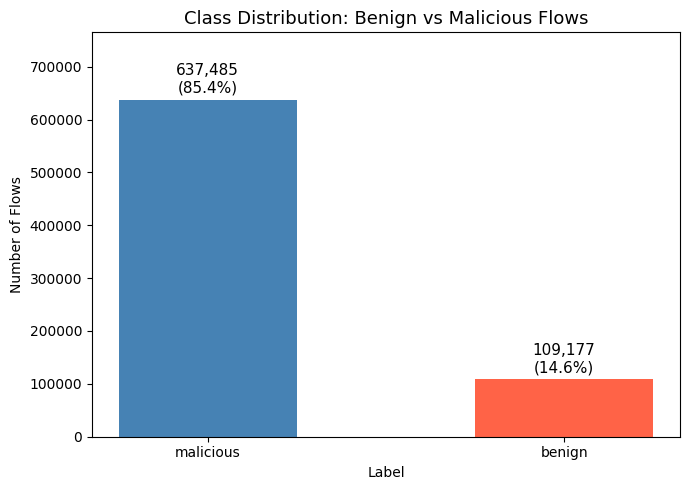

Figure saved.


In [3]:
# Count how many flows are benign and how many are malicious
label_counts = df["label"].value_counts()

# Calculate percentages
total = len(df)
benign_pct = round(label_counts.get("benign", 0) / total * 100, 1)
malicious_pct = round(label_counts.get("malicious", 0) / total * 100, 1)

print(f"Benign: {label_counts.get('benign', 0):,} ({benign_pct}%)")
print(f"Malicious: {label_counts.get('malicious', 0):,} ({malicious_pct}%)")
print()
print("NOTE: Class imbalance is significant - this matters for model evaluation.")
print("Accuracy alone will be misleading. Will use AUPRC and F1 instead.")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["steelblue", "tomato"]
bars = ax.bar(label_counts.index, label_counts.values,
              color=colors[:len(label_counts)], width=0.5)

# Add count and percentage on top of each bar
for bar, (label, count) in zip(bars, label_counts.items()):
    pct = round(count / total * 100, 1)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.01,
            f"{count:,}\n({pct}%)",
            ha="center", va="bottom", fontsize=11)

ax.set_title("Class Distribution: Benign vs Malicious Flows", fontsize=13)
ax.set_xlabel("Label")
ax.set_ylabel("Number of Flows")
ax.set_ylim(0, label_counts.max() * 1.2)

plt.tight_layout()
save_fig("class_distribution.png")
plt.show()
print("Figure saved.")

## Attack type distribution
`detailed_label` names the specific malicious behaviour (e.g. C&C, DDoS, PortScan). This drives the per-attack mitigation recommendations required by the project, so we need to know which attack families are actually present.

Attack types present (malicious flows only):
detailed_label
PartOfAHorizontalPortScan     413024
Okiru                         131308
DDoS                           76371
C&C                            15064
Attack                          1387
C&C-HeartBeat                    229
C&C-FileDownload                  44
C&C-Torii                         30
FileDownload                      16
C&C-HeartBeat-FileDownload        11
C&C-Mirai                          1
Name: count, dtype: int64


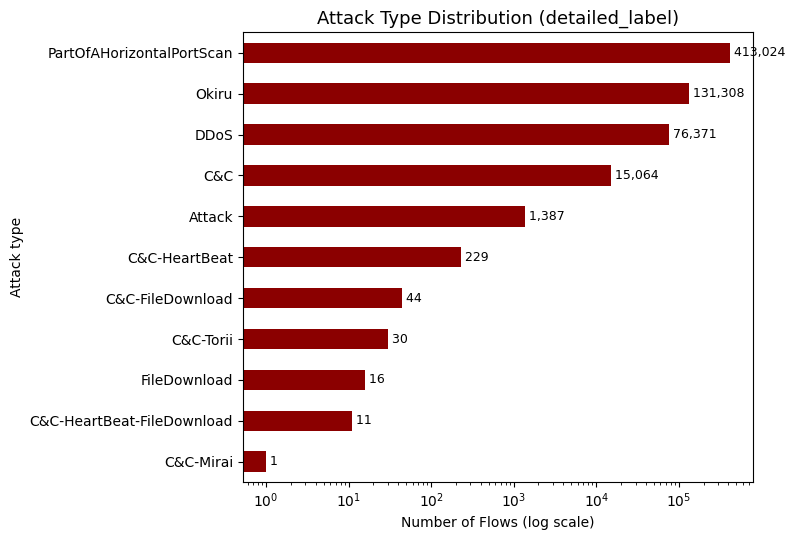

Figure saved.


In [4]:
# Attack types come from detailed_label on malicious flows only.
# Benign flows have detailed_label "-", so we exclude them here.
mal = df[df["label"] == "malicious"].copy()

if len(mal) == 0:
    print("No malicious flows in the loaded sample - check the loader (ROWS_PER_FILE / file list).")
else:
    attack_counts = mal["detailed_label"].str.strip().value_counts()
    print("Attack types present (malicious flows only):")
    print(attack_counts)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(attack_counts))))
    attack_counts.sort_values().plot(kind="barh", color="darkred", ax=ax)
    ax.set_title("Attack Type Distribution (detailed_label)", fontsize=13)
    ax.set_xlabel("Number of Flows (log scale)")
    ax.set_ylabel("Attack type")
    ax.set_xscale("log")   # counts span orders of magnitude
    for i, v in enumerate(attack_counts.sort_values().values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout()
    save_fig("attack_type_distribution.png")
    plt.show()
    print("Figure saved.")

## Protocol distribution by class
Comparing `proto` across benign vs malicious traffic. Many IoT attacks favour specific protocols (e.g. UDP floods, TCP scans), so a class-conditional view is more informative than a single overall count.

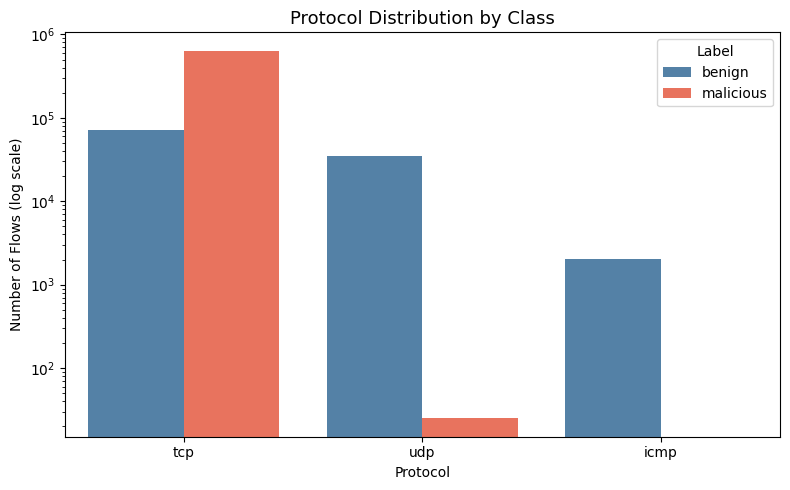

label  benign  malicious
proto                   
icmp     2015          0
tcp     72239     637460
udp     34923         25


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="proto", hue="label",
              order=df["proto"].value_counts().index,
              palette={"benign": "steelblue", "malicious": "tomato"}, ax=ax)
ax.set_title("Protocol Distribution by Class", fontsize=13)
ax.set_xlabel("Protocol")
ax.set_ylabel("Number of Flows (log scale)")
ax.set_yscale("log")   # benign/malicious counts differ by orders of magnitude
ax.legend(title="Label")
plt.tight_layout()
save_fig("protocol_distribution.png")
plt.show()
print(df.groupby(["proto", "label"]).size().unstack(fill_value=0))

## Connection state by class
`conn_state` summarises the TCP/UDP outcome (e.g. S0 = no reply, REJ = rejected, SF = normal completion). Scans and failed connections show distinctive states, so this is one of the most security-relevant categorical features.

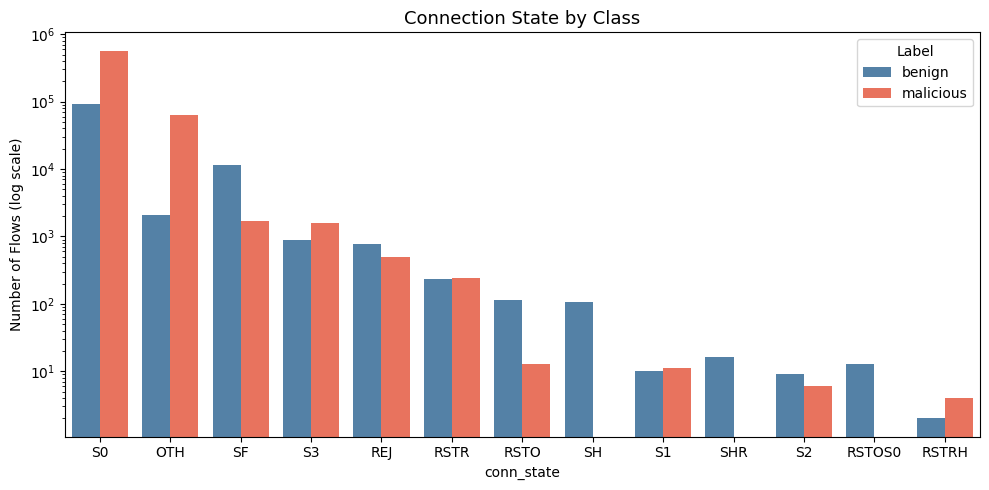

label       benign  malicious
conn_state                   
OTH           2068      63678
REJ            766        496
RSTO           113         13
RSTOS0          13          0
RSTR           231        241
RSTRH            2          4
S0           93619     569742
S1              10         11
S2               9          6
S3             900       1584
SF           11325       1710
SH             105          0
SHR             16          0


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="conn_state", hue="label",
              order=df["conn_state"].value_counts().index,
              palette={"benign": "steelblue", "malicious": "tomato"}, ax=ax)
ax.set_title("Connection State by Class", fontsize=13)
ax.set_xlabel("conn_state")
ax.set_ylabel("Number of Flows (log scale)")
ax.set_yscale("log")
ax.legend(title="Label")
plt.tight_layout()
save_fig("conn_state_distribution.png")
plt.show()
print(df.groupby(["conn_state", "label"]).size().unstack(fill_value=0))

## Top services
`service` is high-cardinality. We show the top values only - this also informs the encoding decision in 02_preprocessing (top-N + 'other' rather than full one-hot).

Top 10 services ("-" means Zeek could not identify the service):
service
-       737515
dns       5413
irc       1652
ssh       1337
http       470
dhcp       180
ssl         95
Name: count, dtype: int64


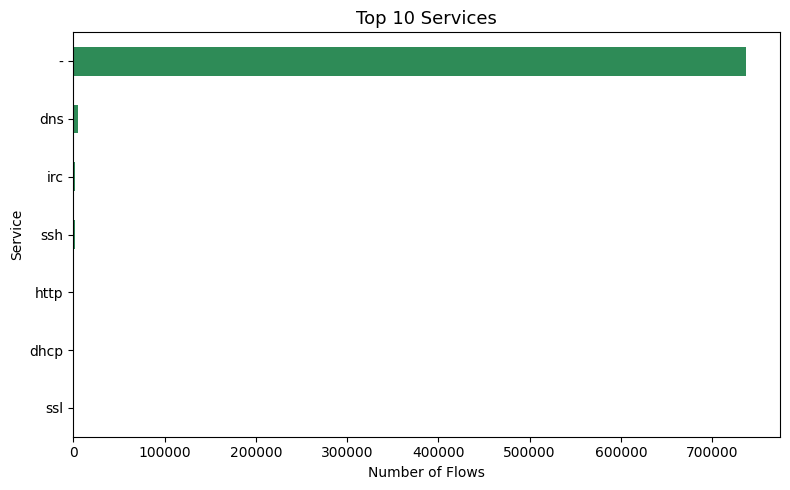

Figure saved.


In [7]:
TOP_N = 10
top_services = df["service"].value_counts().head(TOP_N)
print(f"Top {TOP_N} services (\"-\" means Zeek could not identify the service):")
print(top_services)

fig, ax = plt.subplots(figsize=(8, 5))
top_services.sort_values().plot(kind="barh", color="seagreen", ax=ax)
ax.set_title(f"Top {TOP_N} Services", fontsize=13)
ax.set_xlabel("Number of Flows")
ax.set_ylabel("Service")
plt.tight_layout()
save_fig("service_distribution.png")
plt.show()
print("Figure saved.")

## Numeric feature distributions (benign vs malicious)
Byte and packet counts are highly skewed, so we plot on a log scale and overlay benign vs malicious. Differences here are exactly what the models will learn from (e.g. attacks often send many small packets). Zeek uses "-" for missing values, so we coerce to numeric first ("-" becomes NaN and is dropped only for plotting; the raw df is left untouched for 02_preprocessing).

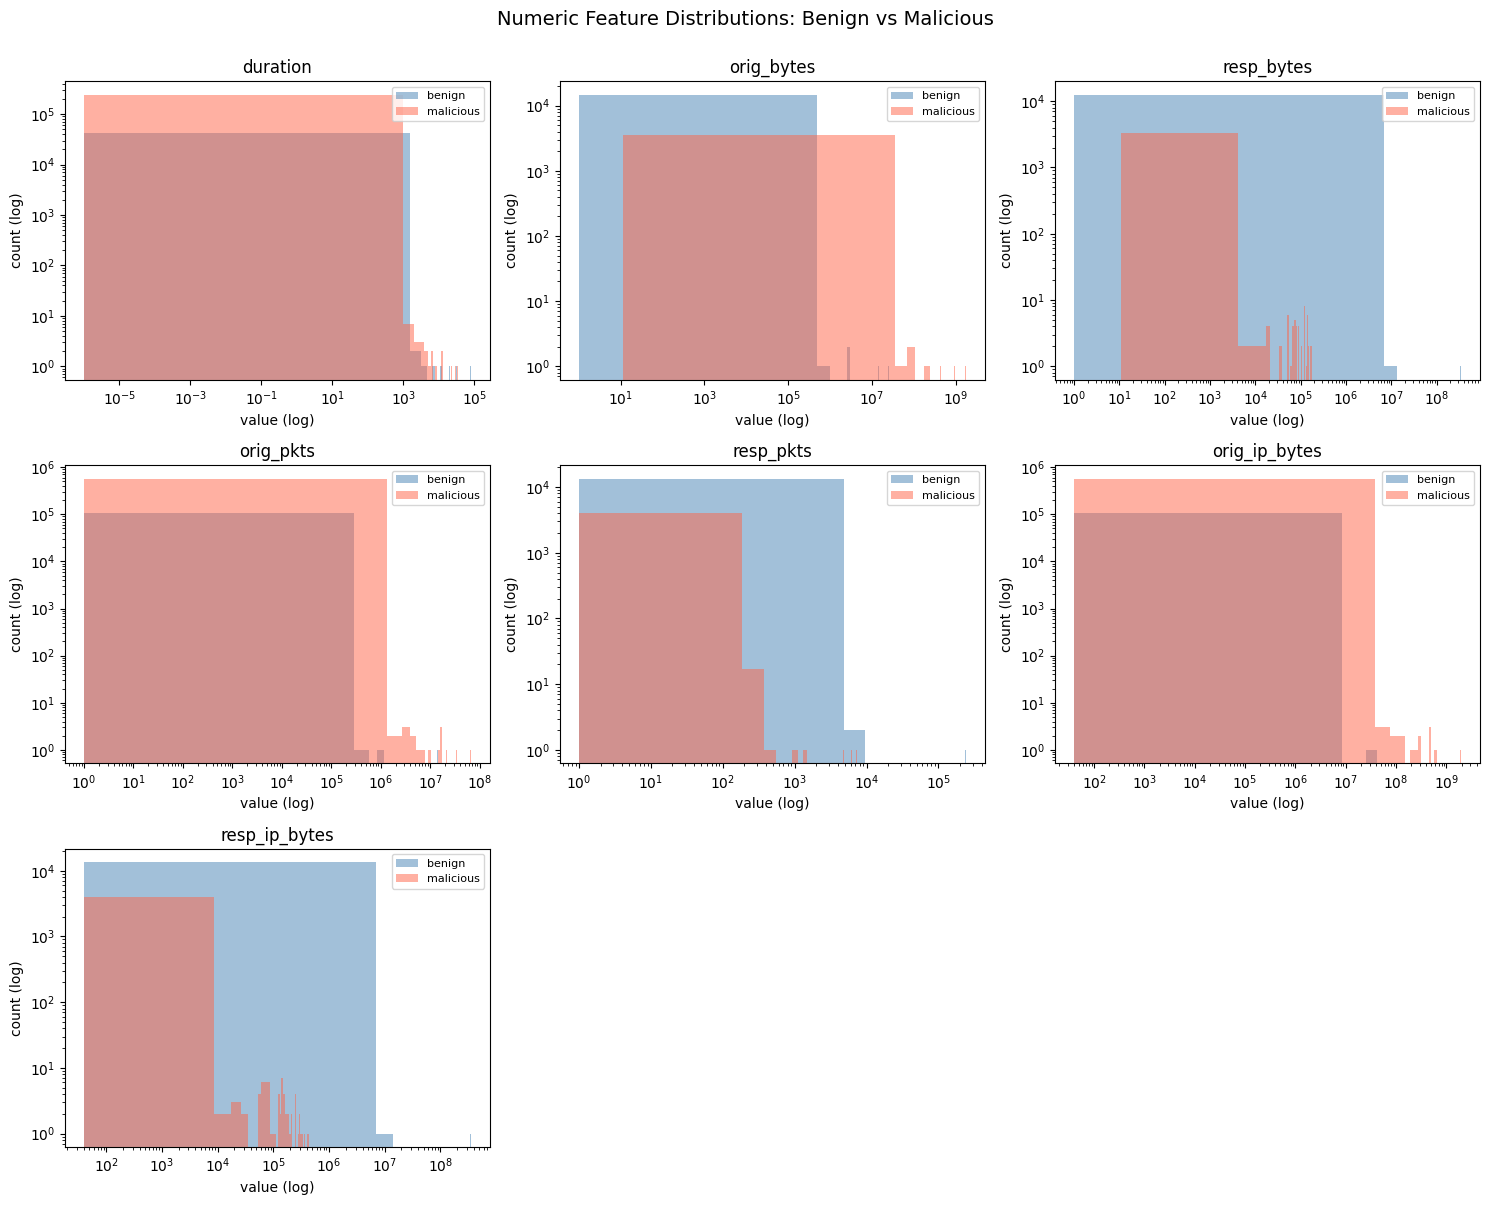

Summary statistics by class:
label                      benign     malicious
duration      count  4.183400e+04  2.412400e+05
              mean   9.451893e+00  2.306933e+00
              std    5.503243e+02  2.004884e+02
              min    1.000000e-06  1.000000e-06
              25%    9.869050e-02  2.000000e-06
              50%    3.106732e+00  5.000000e-06
              75%    3.137480e+00  2.991988e+00
              max    7.884033e+04  4.897682e+04
orig_bytes    count  4.183400e+04  2.412400e+05
              mean   1.180240e+03  1.614406e+04
              std    1.424362e+05  4.195849e+06
              min    0.000000e+00  0.000000e+00
              25%    0.000000e+00  0.000000e+00
              50%    0.000000e+00  0.000000e+00
              75%    4.800000e+01  0.000000e+00
              max    2.505230e+07  1.744830e+09
resp_bytes    count  4.183400e+04  2.412400e+05
              mean   8.588521e+03  4.332331e+01
              std    1.646405e+06  1.971814e+03
           

In [8]:
numeric_features = ["duration", "orig_bytes", "resp_bytes",
                    "orig_pkts", "resp_pkts", "orig_ip_bytes", "resp_ip_bytes"]

# Coerce to numeric for plotting only (does not modify df)
num = df[numeric_features].apply(pd.to_numeric, errors="coerce")
num["label"] = df["label"].values

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for lab, color in [("benign", "steelblue"), ("malicious", "tomato")]:
        vals = num.loc[num["label"] == lab, feat].dropna()
        vals = vals[vals > 0]   # log scale needs positive values
        if len(vals) > 0:
            ax.hist(vals, bins=50, alpha=0.5, label=lab, color=color, log=True)
    ax.set_xscale("log")
    ax.set_title(feat)
    ax.set_xlabel("value (log)")
    ax.set_ylabel("count (log)")
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Numeric Feature Distributions: Benign vs Malicious", fontsize=14, y=1.0)
plt.tight_layout()
save_fig("numeric_feature_distributions.png")
plt.show()

print("Summary statistics by class:")
print(num.groupby("label").describe().T)

## Missing-value summary
Zeek encodes missing values as the string "-". Quantifying this per column justifies the imputation plan in 02_preprocessing (numeric "-" -> 0, categorical "-" -> 'unknown').

In [9]:
missing = (df == "-").sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print('Columns containing "-" (Zeek missing marker):')
print(summary)

Columns containing "-" (Zeek missing marker):
                missing_count  missing_pct
local_orig             746662       100.00
local_resp             746662       100.00
service                737515        98.77
tunnel_parents         536259        71.82
duration               463588        62.09
orig_bytes             463588        62.09
resp_bytes             463588        62.09
detailed_label         109177        14.62
history                  2015         0.27
